# Принятие решений в бизнесе

**Описание проекта**
Крупный интернет-магазин подготовил список гипотез для увеличения выручки. Необходимо приоритизировать гипотезы, запустить A/B-тест и проанализировать результаты. 
 

**Описание данных**

Гипотезы: `/datasets/hypothesis.csv`

- Hypothesis — краткое описание гипотезы;
- Reach — охват пользователей по 10-балльной шкале;
- Impact — влияние на пользователей по 10-балльной шкале;
- Confidence — уверенность в гипотезе по 10-балльной шкале;
- Efforts — затраты ресурсов на проверку гипотезы по 10-балльной шкале. Чем больше значение Efforts, тем дороже проверка гипотезы.


Заказы: `/datasets/orders.csv`

- transactionId — идентификатор заказа;
- visitorId — идентификатор пользователя, совершившего заказ;
- date — дата, когда был совершён заказ;
- revenue — выручка заказа;
- group — группа A/B-теста, в которую попал заказ.


Посетители: `/datasets/visitors.csv`

- date — дата;
- group — группа A/B-теста;
- visitors — количество пользователей в указанную дату в указанной группе A/B-теста


**Ход исследования**

* Загрузка и подготовка данных;
* Приоритизация гипотез;
* Анализ A/B-теста;
* Вывод.


In [1]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from pandas.plotting import register_matplotlib_converters
import warnings

# конвертеры, которые позволяют использовать типы pandas в matplotlib  
register_matplotlib_converters()

### Подготовка данных

In [2]:
data = pd.read_csv('/datasets/hypothesis.csv')

data.head()

,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6
1,"Запустить собственную службу доставки, что сок...",2,5,4,10
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1


In [3]:
# Преобразование всех названий колонок в нижний регистр
data.columns = data.columns.str.lower()
data.head()

,hypothesis,reach,impact,confidence,efforts
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6
1,"Запустить собственную службу доставки, что сок...",2,5,4,10
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   hypothesis  9 non-null      object
 1   reach       9 non-null      int64 
 2   impact      9 non-null      int64 
 3   confidence  9 non-null      int64 
 4   efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


In [5]:
# Датафрейм с данными о заказах
orders = pd.read_csv('/datasets/orders.csv')
orders.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


In [6]:
# Функция для приведения имен столбцов в snake_case
orders.columns = orders.columns.str.replace(r'([A-Z])', r'_\1', regex=True).str.lower().str.strip('_')
orders.head()

,transaction_id,visitor_id,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaction_id  1197 non-null   int64 
 1   visitor_id      1197 non-null   int64 
 2   date            1197 non-null   object
 3   revenue         1197 non-null   int64 
 4   group           1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


In [8]:
# Группировка данных по пользователю и количеству уникальных групп
grouped_users = orders.groupby('visitor_id')['group'].nunique().reset_index()

# Фильтрация пользователей, которые попали в обе группы
users_in_both_groups = grouped_users[grouped_users['group'] > 1]

# Количество пользователей, которые попали в обе группы
print(f"Количество пользователей в обеих группах: {len(users_in_both_groups)}")

Количество пользователей в обеих группах: 58


In [9]:
# Удаление заказов этих пользователей из таблицы
orders = orders[~orders['visitor_id'].isin(users_in_both_groups)]

In [10]:
# Датафрейм с данными о посетителях
visitors = pd.read_csv('/datasets/visitors.csv')
visitors.head()

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [11]:
visitors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [12]:
# Поиск явных дубликатов
# Создаём список имен датафреймов
names = ['data', 'orders', 'visitors']

# Создаём список датафреймов
dataframes = [data, orders, visitors]

# Выводим на экран имя датафрейма и количество строк-дубликатов
for name, df in zip(names, dataframes):
    print(f'{name}: {df.duplicated().sum()}')

data: 0
orders: 0
visitors: 0


**Вывод:**

• **Названия столбцов** были приведены к нижнему регистру;

• **Пропуски** не обнаружены. 

• **Типы данных** нужно привести к формату to_datetime столбец 'date' в таблицах visitors и orders.

• **Дубликаты:** Была сделана проверка на наличие дубликатов строк, они отсутствуют.

• **Пользователи в обеих группах:** 58 пользователей попали в обе группы. Они были удалены.

### Приоритизация гипотез.

В файле /datasets/hypothesis.csv 9 гипотез по увеличению выручки интернет-магазина с указанными параметрами Reach, Impact, Confidence, Effort.

Применим **фреймворк ICE** для приоритизации гипотез. Отсортируем их по убыванию приоритета.

In [13]:
pd.set_option('max_colwidth', 200)

data['ICE'] = (data['impact'] * data['confidence'] / data['efforts']).round(2)

data[['hypothesis', 'ICE']].sort_values(by='ICE', ascending=False)

,hypothesis,ICE
8,"Запустить акцию, дающую скидку на товар в день рождения",16.20
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",13.33
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",11.20
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",8.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",7.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",1.33
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",1.12
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",1.00


Применим **фреймворк RICE** для приоритизации гипотез. Отсортируем их по убыванию приоритета.

In [14]:
pd.set_option('max_colwidth', 200)
data['RICE'] = data['reach'] * data['impact'] * data['confidence'] / data['efforts']

data[['hypothesis', 'RICE']].sort_values(by='RICE', ascending=False)

,hypothesis,RICE
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",112.0
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",56.0
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",40.0
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",40.0
8,"Запустить акцию, дающую скидку на товар в день рождения",16.2
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",9.0
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",4.0
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",4.0
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3.0


В **RICE** добавляется новый параметр — **Reach** (охват). Он учитывает, сколько пользователей или объектов затронет предлагаемая гипотеза. 
При добавлении параметра Reach гипотезы, которые затрагивают большее количество пользователей, получают более высокие баллы по RICE. Это может смещать приоритеты, так как гипотезы с меньшим влиянием, но с большим охватом могут стать важнее, чем гипотезы с сильным влиянием, но затрагивающие меньшее число пользователей.

**Вывод:**  Самая приоритетная гипотеза: "*Добавить форму подписки на все основные страницы...*" гипотеза с индексом 7 (RICE - 112).
Далее идут гипотеза 2 "*Добавить блоки рекомендаций..*" (RICE - 56), "*Добавить два новых канала...*" и "*Показать на главной странице баннеры с актуальными акциями...*" (RICE - 40).

### Анализ A/B-теста

Мы провели A/B-тест и получили результаты:

#### Строим график кумулятивной выручки по группам. Сделайте выводы и предположения.

In [15]:
orders['date'] = orders['date'].map(
    lambda x: dt.datetime.strptime(x, '%Y-%m-%d')
)

visitors['date'] = visitors['date'].map(
    lambda x: dt.datetime.strptime(x, '%Y-%m-%d')
)

In [16]:
datesGroups = orders[['date', 'group']].drop_duplicates()

ordersAggregated = datesGroups.apply(
    lambda x: orders[
        np.logical_and(
            orders['date'] <= x['date'], orders['group'] == x['group']
        )
    ].agg(
        {
            'date': 'max',
            'group': 'max',
            'transaction_id': 'nunique',
            'visitor_id': 'nunique',
            'revenue': 'sum',
        }
    ),
    axis=1,
).sort_values(by=['date', 'group'])

visitorsAggregated = datesGroups.apply(
    lambda x: visitors[
        np.logical_and(
            visitors['date'] <= x['date'], visitors['group'] == x['group']
        )
    ].agg({'date': 'max', 'group': 'max', 'visitors': 'sum'}),
    axis=1,
).sort_values(by=['date', 'group'])

cumulativeData = ordersAggregated.merge(
    visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group']
)
cumulativeData.columns = [
    'date',
    'group',
    'orders',
    'buyers',
    'revenue',
    'visitors',
]

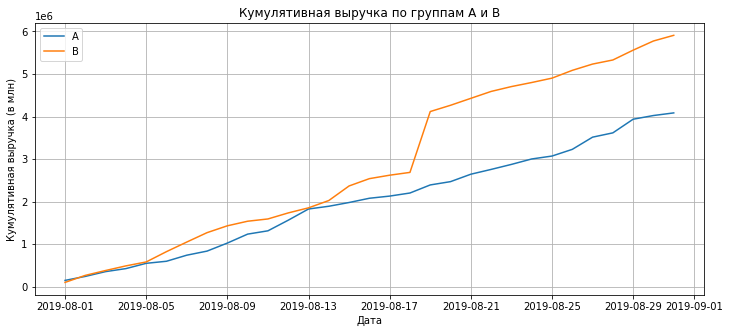

In [17]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе A
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]

# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]

plt.figure(figsize=(12, 5))
# Строим график выручки группы А
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='A')

# Строим график выручки группы B
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='B')

plt.title('Кумулятивная выручка по группам А и В')
plt.xlabel('Дата')
plt.ylabel('Кумулятивная выручка (в млн)')
plt.legend()
plt.grid()
plt.show()

**Вывод:** Кумулятивная выручка в группе B с самого начала растёт немного быстрее, чем в группе A. Это преимущество сохраняется на протяжении всего теста, и разрыв между группами увеличивается по мере его проведения. Примерно 17 августа в группе B происходит резкий скачок кумулятивной выручки. Это, скорее всего, связано с аномально большим заказом или несколькими крупными заказами, которые существенно увеличили общую выручку в группе. При заключительном анализе их стоит удалить. 

В группе A рост выручки более равномерный, без резких скачков.

#### Постройте график кумулятивного среднего чека по группам. Сделайте выводы и предположения.

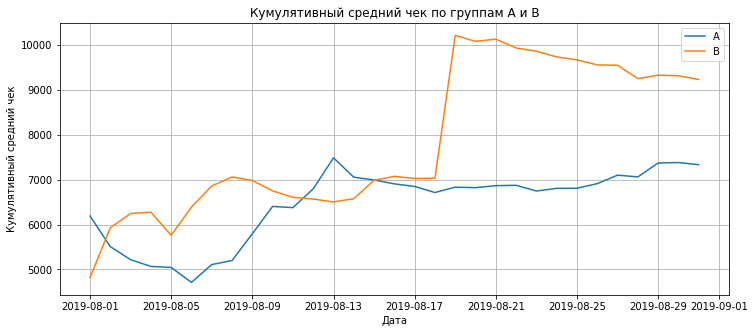

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue']/cumulativeRevenueA['orders'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'], label='B')

plt.title('Кумулятивный средний чек по группам А и В')
plt.xlabel('Дата')
plt.ylabel('Кумулятивный средний чек')
plt.legend()
plt.grid()
plt.show()

**Вывод:** Кумулятивный средний чек в группе A начинает снижаться в начале эксперимента, достигает минимума примерно 5-6 августа, а затем начинает медленно расти, оставаясь относительно стабильным до конца эксперимента.
В группе B наблюдается резкий скачок среднего чека примерно 17 августа, после чего происходит постепенное снижение. Этот скачок может быть вызван аномально большими заказами, которые сильно повлияли на результаты.

Скорее всего, принимать решение по этой метрике рано. Или требуется провести анализ выбросов и, возможно, исключить их из данных, чтобы получить более чистые результаты.


#### Постройте график относительного изменения кумулятивного среднего чека группы B к группе A. Сделайте выводы и предположения.

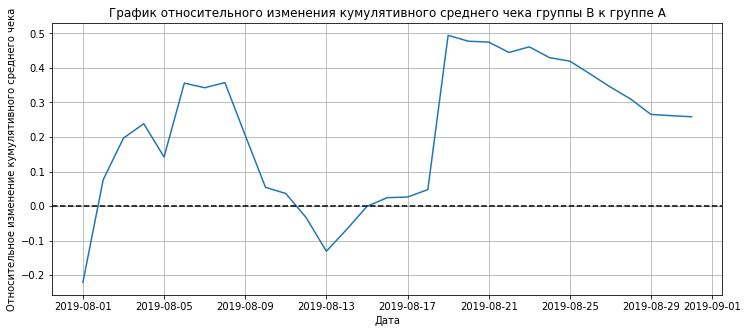

In [19]:
# собираем данные в одном датафрейме
mergedCumulativeRevenue = cumulativeRevenueA.merge(cumulativeRevenueB, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

# cтроим отношение средних чеков
plt.figure(figsize=(12, 5))
plt.plot(mergedCumulativeRevenue['date'], (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])/(mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])-1)
# добавляем ось X

plt.title('График относительного изменения кумулятивного среднего чека группы B к группе A')
plt.xlabel('Дата')
plt.ylabel('Относительное изменение кумулятивного среднего чека')
plt.axhline(y=0, color='black', linestyle='--')
plt.grid()
plt.show()

Группа B демонстрирует значительное колебание среднего чека в сравнении с группой A, что может быть связано с наличием выбросов.
В начале теста наблюдаются значительные колебания, что связано с небольшим количеством данных и чувствительностью к отдельным заказам. Примерно 13 августа произошло резкое снижение среднего чека группы B по отношению к группе A, вероятно, из-за крупных заказов в группе A или временного падения в группе B. 17 августа виден резкий рост в группе B из-за аномально крупных заказов. После этого разница между группами постепенно снижается, но средний чек группы B всё ещё остаётся выше.

### Постройте график кумулятивного среднего количества заказов на посетителя по группам. Сделайте выводы и предположения.

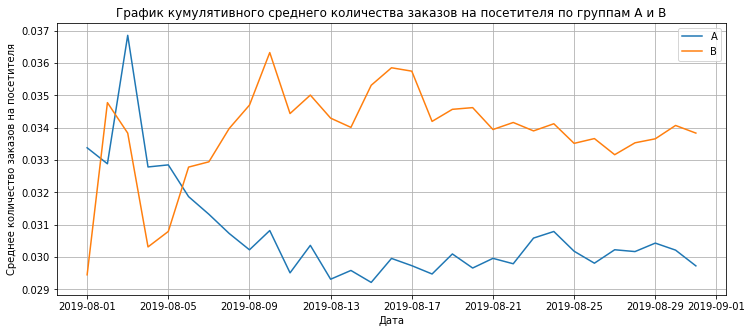

In [20]:
# считаем среднее количество заказов на посетителя
cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors']

# отделяем данные по группе A
cumulativeDataA = cumulativeData[cumulativeData['group']=='A']

# отделяем данные по группе B
cumulativeDataB = cumulativeData[cumulativeData['group']=='B']

# строим графики
plt.figure(figsize=(12, 5))
plt.title('График кумулятивного среднего количества заказов на посетителя по группам А и В')
plt.xlabel('Дата')
plt.ylabel('Среднее количество заказов на посетителя')
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B')
plt.legend()
plt.grid()
plt.show()

В начале теста сегмент A имел большее кумулятивное среднее количество заказов, но со временем сегмент B значительно превзошел сегмент A. Группа B стабильно показывает большее количество заказов на посетителя по сравнению с группой A, особенно после 9 августа, где её показатели остаются на высоком уровне. В группе A наблюдается резкий спад после первоначального скачка, и с середины эксперимента её показатели стабильно ниже. Резкие изменения в начале могут быть вызваны выбросами, что требует дополнительного анализа данных для исключения аномальных значений.

#### Постройте график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. Сделайте выводы и предположения.

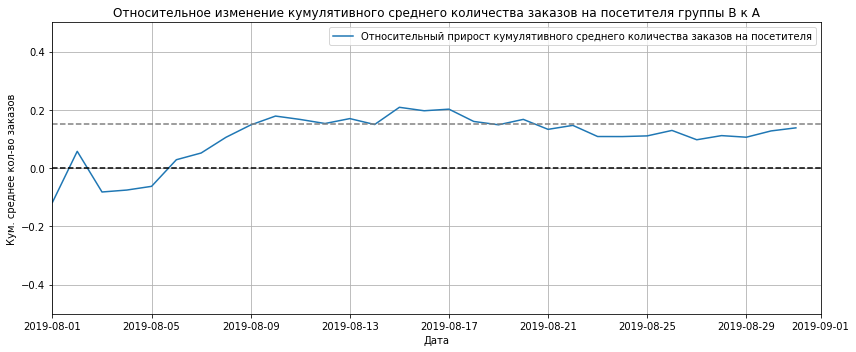

In [21]:
mergedCumulativeConversions = cumulativeDataA[['date','conversion']].merge(cumulativeDataB[['date','conversion']], left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

# Создаем фигуру с размерами и заголовком
plt.figure(figsize=(12, 5))
plt.title('Относительное изменение кумулятивного среднего количества заказов на посетителя группы B к A')

# Строим график
plt.plot(mergedCumulativeConversions['date'], 
         mergedCumulativeConversions['conversionB']/mergedCumulativeConversions['conversionA'] - 1, 
         label="Относительный прирост кумулятивного среднего количества заказов на посетителя")

plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.15, color='grey', linestyle='--')
plt.axis(["2019-08-01", '2019-09-01', -0.5, 0.5])
plt.xlabel('Дата')
plt.ylabel('Кум. среднее кол-во заказов')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Почти с самого начала теста группа B лидирует по метрике: становится лучше и лучше, стабилизируясь около прироста в 15% относительно группы A.


#### Постройте точечный график количества заказов по пользователям. Сделайте выводы и предположения.

In [22]:
ordersByUsers = (
    orders.groupby('visitor_id', as_index=False)
    .agg({'transaction_id': 'nunique'})
)

ordersByUsers.columns = ['visitor_id', 'orders']

ordersByUsers.sort_values(by='orders', ascending=False).head(10)

,visitor_id,orders
1023,4256040402,11
591,2458001652,11
569,2378935119,9
487,2038680547,8
44,199603092,5
744,3062433592,5
55,237748145,5
917,3803269165,5
299,1230306981,5
897,3717692402,5


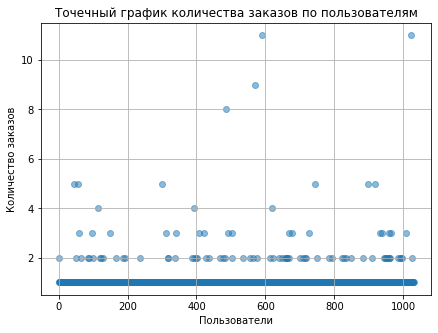

In [23]:
# серия из чисел от 0 до количества наблюдений в ordersByUsers
x_values = pd.Series(range(0, len(ordersByUsers)))
plt.figure(figsize=(7, 5))
plt.scatter(x_values, ordersByUsers['orders'], alpha=0.5) 
plt.title('Точечный график количества заказов по пользователям')
plt.xlabel('Пользователи')
plt.ylabel('Количество заказов')
plt.grid()
plt.show()

Пользователей, заказавших более двух раз, совсем мало. Они вполне могут быть аномальными.

2 заказа — нормально или много? Ответьте на этот вопрос, посчитав выборочные перцентили. Посчитайте 95-й и 99-й перцентили количества заказов на пользователя. Выберите границу для определения аномальных пользователей.

#### Посчитайте 95-й и 99-й перцентили количества заказов на пользователя. Выберите границу для определения аномальных пользователей.

In [24]:
# Метод np.percentile('column', [percentile1, percentile2, percentile3]) находит перцентили.
print(np.percentile(ordersByUsers['orders'], [90, 95, 99]))

[1. 2. 4.]


Только 10% пользователей заказывали более 1 раза. Не более 5% пользователей совершали больше двух заказов. И не более 1% пользователей делали больше 4 заказов. В качестве границы выбросов можно установить 95-й перцентиль.

#### Постройте точечный график стоимостей заказов. Сделайте выводы и предположения.

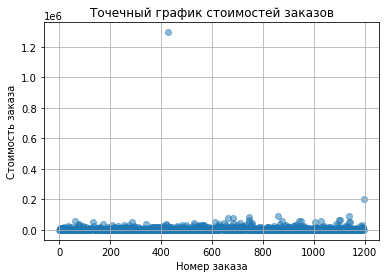

In [25]:
x_values = pd.Series(range(0,len(orders['revenue'])))
plt.scatter(x_values, orders['revenue'], alpha=0.5)
plt.title('Точечный график стоимостей заказов')
plt.xlabel('Номер заказа')
plt.ylabel('Стоимость заказа')
plt.grid()
plt.show()

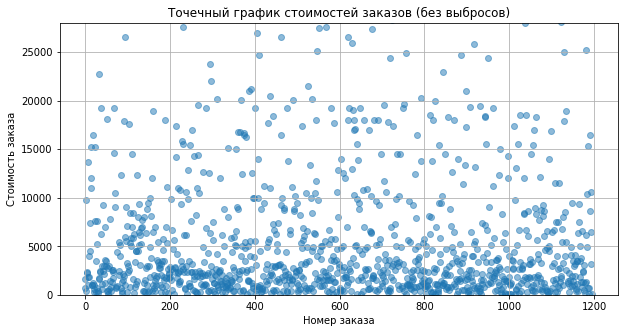

In [26]:
# Второй график: ограничим ось Y для исключения выбросов
plt.figure(figsize=(10, 5))
plt.scatter(x_values, orders['revenue'], alpha=0.5)
plt.title('Точечный график стоимостей заказов (без выбросов)')
plt.xlabel('Номер заказа')
plt.ylabel('Стоимость заказа')
plt.ylim(0, orders['revenue'].quantile(0.95))  # Ограничиваем Y до 95-го перцентиля
plt.grid()
plt.show()

Большинство заказов имеют относительно небольшую стоимость. Выделяются два явных выброса: один заказ около отметки 1.2 миллиона, а другой около 200 тысяч.

#### Посчитайте 95-й и 99-й перцентили стоимости заказов. Выберите границу для определения аномальных заказов.

In [27]:
np.percentile(orders['revenue'], [90, 95, 99])

array([18168. , 28000. , 58233.2])

Не более 5% заказов дороже 28 000 рублей и не более 1% дороже 58 233 рублей. В качестве границы выбросов установим 95-й перцентиль.

#### Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным. Сделайте выводы и предположения.

Сформулируем гипотезы. Нулевая (H₀): различий в среднем количестве заказов между группами нет. Альтернативная (H₁): различия в среднем между группами есть.

Для проверки гипотез используем критерий Манна-Уитни, так как он подходит для сравнения двух независимых выборок, даже если данные не имеют нормального распределения. В нашем случае, количество заказов на пользователя может быть сильно смещенным, с наличием выбросов и неравномерным распределением.

Примем стандартное значение α = 0.05. Это означает, что мы готовы принять 5% вероятность ошибочного отклонения нулевой гипотезы.

In [28]:
ordersByUsersA = (
    orders[orders['group'] == 'A']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
ordersByUsersA.columns = ['visitor_id', 'orders']

ordersByUsersB = (
    orders[orders['group'] == 'B']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
ordersByUsersB.columns = ['visitor_id', 'orders'] 

Посчитаем статистическую значимость различия в среднем количестве заказов между группами.

In [29]:
sampleA = pd.concat([ordersByUsersA['orders'],pd.Series(0, index=np.arange(visitors[visitors['group'] == 'A']['visitors'].sum() - len(ordersByUsersA['orders'])), name='orders')],axis=0)

sampleB = pd.concat([ordersByUsersB['orders'],pd.Series(0, index=np.arange(visitors[visitors['group'] == 'B']['visitors'].sum() - len(ordersByUsersB['orders'])), name='orders')],axis=0)


print('Значение P-value:', "{0:.3f}".format(stats.mannwhitneyu(sampleA, sampleB)[1]))

print('Относительная разница между группами:',"{0:.3f}".format((sampleB.mean()/sampleA.mean()-1)))


Значение P-value: 0.017
Относительная разница между группами: 0.138


**Вывод** P-value ниже стандартного порога 0.05, что означает статистически значимые различия между группами A и B. Это говорит о том, что вероятность получить такие различия случайно менее 1.7%. Таким образом, гипотеза о равенстве средних значений числа заказов на посетителя между группами A и B может быть отвергнута в пользу гипотезы о существовании различий.

В группе B среднее количество заказов на посетителя выросло на 13.8% по сравнению с группой A. Это существенный прирост, который указывает на положительный эффект тестируемого изменения.

#### Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «сырым» данным. Сделайте выводы и предположения.

Теперь проверим статистическую значимость различий в среднем чеке между сегментами. Нулевая гипотеза: различий в среднем чеке между группами нет. Альтернативная гипотеза: различия в среднем чеке между группами есть.

Чтобы рассчитать статистическую значимость различий в среднем чеке, передадим критерию mannwhitneyu() данные о выручке с заказов. 
А ещё найдём относительные различия в среднем чеке между группами:

In [30]:
print('p-value:', '{0:.3f}'.format(stats.mannwhitneyu(orders[orders['group']=='A']['revenue'], orders[orders['group']=='B']['revenue'])[1]))
print('Относительный прирост среднего чека заказов группы B:', '{0:.3f}'.format(orders[orders['group']=='B']['revenue'].mean()/orders[orders['group']=='A']['revenue'].mean()-1))

p-value: 0.729
Относительный прирост среднего чека заказов группы B: 0.259


**Вывод:** P-value значительно больше 0.05. То есть вероятность того, что наблюдаемые различия в среднем чеке между группами произошли случайно, составляет 72.9%. Это слишком высокое значение для того, чтобы отвергнуть нулевую гипотезу.
Следовательно, нулевая гипотеза о том, что различий в среднем чеке между группами нет, не может быть отвергнута.

Несмотря на отсутствие статистической значимости, наблюдается прирост среднего чека в группе B на 25.9% по сравнению с группой A. 

#### Исключаем аномальные значения из данных

Исключим аномальные значения из данных, чтобы более точно оценить различия между группами, так как они могут искажать результаты и приводить к некорректным выводам.

Примем за аномальных пользователей тех, кто совершил от 3 заказов или совершил заказ дороже 28 000 рублей. Так мы уберём 5% пользователей с наибольшим числом заказов и от 1% до 5% пользователей с дорогими заказами. Сделаем срезы пользователей с числом заказов больше 2-х — usersWithManyOrders и пользователей, совершивших заказы дороже 28 000 — usersWithExpensiveOrders. Объединим их в таблице abnormalUsers 

In [31]:
usersWithManyOrders = pd.concat(
    [
        ordersByUsersA[ordersByUsersA['orders'] > np.percentile(ordersByUsers['orders'], 95)]['visitor_id'],
        ordersByUsersB[ordersByUsersB['orders'] > np.percentile(ordersByUsers['orders'], 95)]['visitor_id'],
    ],
    axis=0,
)
usersWithExpensiveOrders = orders[orders['revenue'] > np.percentile(orders['revenue'], 95)]['visitor_id']
abnormalUsers = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)

print(abnormalUsers.head(5))

# Узнаем, сколько всего аномальных пользователей
print('Количество аномальных пользователей:', abnormalUsers.shape[0])

1099    148427295
18      199603092
928     204675465
23      237748145
37      249864742
Name: visitor_id, dtype: int64
Количество аномальных пользователей: 74


In [32]:
sampleAFiltered = pd.concat(
    [
        ordersByUsersA[
            np.logical_not(ordersByUsersA['visitor_id'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                visitors[visitors['group'] == 'A']['visitors'].sum() - len(ordersByUsersA['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

sampleBFiltered = pd.concat(
    [
        ordersByUsersB[
            np.logical_not(ordersByUsersB['visitor_id'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                visitors[visitors['group'] == 'B']['visitors'].sum() - len(ordersByUsersB['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

#### Посчитайте статистическую значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным. Сделайте выводы и предположения.

Сформулируем гипотезы. Нулевая (H₀): различий в среднем количестве заказов между группами нет. Альтернативная (H₁): различия в среднем между группами есть.

Для проверки гипотез используем критерий Манна-Уитни. α = 0.05.

In [33]:
# Применим статистический критерий Манна-Уитни к полученным выборкам

print('p-value:', '{0:.3f}'.format(stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]))
print('Относительный прирост среднего числа заказов группы B:',
      '{0:.3f}'.format(sampleBFiltered.mean()/sampleAFiltered.mean()-1))

p-value: 0.013
Относительный прирост среднего числа заказов группы B: 0.173


**Вывод** Результаты по среднему количеству заказов изменились не сильно. P-value снова ниже стандартного порога 0.05, что означает статистически значимые различия между группами A и B. Гипотеза о равенстве средних значений числа заказов на посетителя между группами A и B может быть отвергнута.

В группе B среднее количество заказов на посетителя выросло до 17.3% в сравнении с результатами по "сырым" данным в 13.8%.


#### Посчитайте статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным. Сделайте выводы и предположения.

Нулевая гипотеза: различий в среднем чеке между группами нет. Альтернативная гипотеза: различия в среднем чеке между группами есть.

Передадим критерию mannwhitneyu() данные о выручке с заказов. А ещё найдём относительные различия в среднем чеке между группами:

In [34]:
print(
    'p-value:',
    '{0:.3f}'.format(
        stats.mannwhitneyu(
            orders[
                np.logical_and(
                    orders['group'] == 'A',
                    np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
                )
            ]['revenue'],
            orders[
                np.logical_and(
                    orders['group'] == 'B',
                    np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
                )
            ]['revenue'],
        )[1]
    )
)

print(
    'Относительный прирост среднего чека заказов группы B:',
    "{0:.3f}".format(
        orders[
            np.logical_and(
                orders['group'] == 'B',
                np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
            )
        ]['revenue'].mean()
        / orders[
            np.logical_and(
                orders['group'] == 'A',
                np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
            )
        ]['revenue'].mean()
        - 1
    )
)


p-value: 0.738
Относительный прирост среднего чека заказов группы B: -0.020


**Вывод:** P-value значительно больше 0.05, примерно такое же высокое (0.738 по сравнению с 0.729),  что подтверждает отсутствие статистически значимых различий.
Нулевая гипотеза о том, что различий в среднем чеке между группами нет, не может быть отвергнута.

После очистки данных прирост среднего чека изменился с положительного (0.259) на отрицательный (-0.020), что указывает на незначительное снижение среднего чека в группе B по сравнению с группой A.

#### Примите решение по результатам теста и объясните его. Варианты решений:
1. Остановить тест, зафиксировать победу одной из групп.
2. Остановить тест, зафиксировать отсутствие различий между группами.
3. Продолжить тест.

**Вывод:**  

**Самая приоритетная гипотеза:** "*Добавить форму подписки на все основные страницы...*" гипотеза с индексом 7 (RICE - 112).
Далее идут гипотеза 2 "*Добавить блоки рекомендаций..*" (RICE - 56), "*Добавить два новых канала...*" и "*Показать на главной странице баннеры с актуальными акциями...*" (RICE - 40).

**Результаты A/B-теста**

**Кумулятивная выручка** в группе B с самого начала растёт немного быстрее, чем в группе A. Это преимущество сохраняется на протяжении всего теста, и разрыв между группами увеличивается по мере его проведения. Примерно 17 августа в группе B происходит резкий скачок кумулятивной выручки. Это, скорее всего, связано с аномально большим заказом или несколькими крупными заказами, которые существенно увеличили общую выручку в группе. При заключительном анализе их стоит удалить. В группе A рост выручки более равномерный, без резких скачков.

**Кумулятивный средний чек** в группе A начинает снижаться в начале эксперимента, достигает минимума примерно 5-6 августа, а затем начинает медленно расти, оставаясь относительно стабильным до конца эксперимента.
В группе B наблюдается резкий скачок среднего чека примерно 17 августа, после чего происходит постепенное снижение. Этот скачок может быть вызван аномально большими заказами, которые сильно повлияли на результаты. Скорее всего, принимать решение по этой метрике рано. Или требуется провести анализ выбросов и, возможно, исключить их из данных, чтобы получить более чистые результаты. 

Группа B демонстрирует значительное колебание среднего чека в сравнении с группой A, что может быть связано с наличием выбросов. В начале теста наблюдаются значительные колебания, что связано с небольшим количеством данных и чувствительностью к отдельным заказам. Примерно 13 августа произошло резкое снижение среднего чека группы B по отношению к группе A, вероятно, из-за крупных заказов в группе A или временного падения в группе B. 17 августа виден резкий рост в группе B из-за аномально крупных заказов. После этого разница между группами постепенно снижается, но средний чек группы B всё ещё остаётся выше.

В начале теста сегмент A имел большее **кумулятивное среднее количество заказов**, но со временем сегмент B значительно превзошел сегмент A. Группа B стабильно показывает большее количество заказов на посетителя по сравнению с группой A, особенно после 9 августа, где её показатели остаются на высоком уровне. В группе A наблюдается резкий спад после первоначального скачка, и с середины эксперимента её показатели стабильно ниже. Резкие изменения в начале могут быть вызваны выбросами, что требует дополнительного анализа данных для исключения аномальных значений.

**Выводы по А/B тесту:**

Имеющиеся факты:

Есть статистически значимые различия в среднем количестве заказов на посетителя между группами A и B и по «сырым», и по «очищенным» данным. P-value ниже стандартного порога 0.05, что означает статистически значимые различия между группами A и B. Это говорит о том, что вероятность получить такие различия случайно менее 1.7%. Таким образом, гипотеза о равенстве средних значений числа заказов на посетителя между группами A и B может быть отвергнута в пользу гипотезы о существовании различий.
В группе B среднее количество заказов на посетителя выросло на 13.8% по сравнению с группой A. Это существенный прирост, который указывает на положительный эффект тестируемого изменения.

Нет статистически значимого различия по среднему чеку между группами ни по «сырым», ни по данным после фильтрации аномалий. После очистки данных прирост среднего чека изменился с положительного (0.259) на отрицательный (-0.020), что указывает на незначительное снижение среднего чека в группе B по сравнению с группой A.

График относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. Почти с самого начала теста группа B лидирует по метрике: становится лучше и лучше, стабилизируясь около прироста в 20% относительно группы A. 

график относительного изменения кумулятивного среднего чека группы B к группе A. Группа B демонстрирует значительное колебание среднего чека в сравнении с группой A, что может быть связано с наличием выбросов. В начале теста наблюдаются значительные колебания, что связано с небольшим количеством данных и чувствительностью к отдельным заказам. Примерно 13 августа произошло резкое снижение среднего чека группы B по отношению к группе A, вероятно, из-за крупных заказов в группе A или временного падения в группе B. 17 августа виден резкий рост в группе B из-за аномально крупных заказов. После этого разница между группами постепенно снижается, но средний чек группы B всё ещё остаётся выше.

**Решение:** Остановить тест, зафиксировать победу группы B.

**Обоснование:** Положительное влияние тестируемого изменения на количество заказов в группе B можно зафиксировать как победу по этой метрике. Средний чек между группами не является решающим фактором, так как существенного влияния на итоговый результат не выявлено. Рост по количеству заказов является устойчивым, а средний чек не оказывает значительного влияния на общую картину.
